In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
# load models
paths = [
    '../training/runs/baseline/baseline_seed9',
    '../training/runs/baseline/baseline_seed87',
    '../training/runs/baseline/baseline_seed333',
]

models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
model = models[0]

# whitening

In [4]:
# load batches and save feature vecs
num_batches = 5

features = {}
for mode in ['train', 'validation']:
    mode_features = []
    for key in data_keys:
        batch_features = []
        for i, batch in enumerate(dataloaders[mode][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature.detach().cpu()
            batch_features.append(feature)
        mode_features.append(torch.cat(batch_features))

    flattened = torch.cat([f.flatten(0, 1) for f in mode_features])
    features[mode] = flattened

In [5]:
# helper for mu, cov and corr computation
def get_stats(X):
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    std = cov.diag().sqrt()
    cor = cov / torch.outer(std, std)
    return mu, cov, cor

In [6]:
val_mu, val_cov, val_cor = get_stats(features['validation'])

In [7]:
# whiten
train_mu, train_cov, train_cor = get_stats(features['train'])

eye = torch.eye(train_cov.shape[0])
L = torch.linalg.cholesky(train_cov + 1e-5 * eye)
W = torch.linalg.inv(L).T

X = features['validation']
Xw = (X - train_mu) @ W

white_mu, white_cov, white_cor = get_stats(Xw)

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_corr_matrices(corr1, corr2, labels=None,
                       titles=("Matrix 1", "Matrix 2"),
                       cmap="RdBu_r",
                       bins=30):

    # ------------------------------------------------------------
    # 1. Get the ordering from seaborn's clustering
    # ------------------------------------------------------------
    def get_cluster_order(corr):
        # Temporary clustermap only to obtain the ordering
        g = sns.clustermap(
            corr,
            row_cluster=True,
            col_cluster=True,
            cmap=cmap,
            xticklabels=False,
            yticklabels=False,
        )

        order = g.dendrogram_row.reordered_ind
        plt.close(g.fig)

        return order

    order = get_cluster_order(corr1)
    order1 = order
    order2 = order

    # If both matrices have the same variables, you may want
    # exactly the same ordering for direct comparison.
    # In that case, use:
    #
    # order = get_cluster_order(corr1)
    # order1 = order2 = order

    corr1_ordered = np.asarray(corr1)[np.ix_(order1, order1)]
    corr2_ordered = np.asarray(corr2)[np.ix_(order2, order2)]

    if labels is not None:
        labels1 = np.asarray(labels)[order1]
        labels2 = np.asarray(labels)[order2]
    else:
        labels1 = labels2 = None

    # ------------------------------------------------------------
    # 2. Fixed color scale centered at zero
    # ------------------------------------------------------------
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # ------------------------------------------------------------
    # 3. Figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 5),
        constrained_layout=True
    )

    matrices = [corr1_ordered, corr2_ordered]
    ordered_labels = [labels1, labels2]

    # ------------------------------------------------------------
    # 4. Histogram of off-diagonal values
    #    Use the same symmetric x-limits and ticks for both
    # ------------------------------------------------------------

    # Get off-diagonal values from both matrices
    off_diag_values = []

    for matrix in matrices:
        off_diag = matrix[~np.eye(matrix.shape[0], dtype=bool)]
        off_diag_values.append(off_diag)

    # Maximum absolute off-diagonal value across BOTH matrices
    max_abs = max(
        np.max(np.abs(values))
        for values in off_diag_values
    )

    # Optional: round upward to a clean value
    xlim = np.ceil(max_abs * 10) / 10

    # Common ticks, symmetric around zero
    ticks = np.linspace(-xlim, xlim, 5)

    ax_letters = [['A', 'C'], ['B', 'D']]

    for ax, matrix, matrix_labels, title, off_diag, letters in zip(
        axes,
        matrices,
        ordered_labels,
        titles,
        off_diag_values,
        ax_letters,
    ):
        # Heatmap
        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            norm=norm,
            square=True,
            xticklabels=matrix_labels if matrix_labels is not None else False,
            yticklabels=matrix_labels if matrix_labels is not None else False,
            cbar=False,
        )

        ax.set_title(title)

        ax.text(
            0.03, 1.0, letters[0],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='bottom',
            ha='right',
        )

        # Histogram inset
        hist_ax = inset_axes(
            ax,
            width="42%",
            height="42%",
            loc="upper right",
            # borderpad=1.0,
        )

        hist_ax.hist(
            off_diag,
            bins=bins,
            range=(-xlim, xlim),
            density=True,
            color='black',
        )

        # Same limits and ticks for both histograms
        hist_ax.set_xlim(-xlim, xlim)
        hist_ax.set_xticks(ticks)

        hist_ax.tick_params(
            axis="both",
            labelsize=7,
            length=2,
        )

        hist_ax.set_facecolor("white")

        hist_ax.text(
            0.1, 0.87, letters[1],
            transform=hist_ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='bottom',
            ha='right',
        )

    # One shared colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=axes,
        shrink=0.8,
        label="Correlation",
    )

    return fig, axes

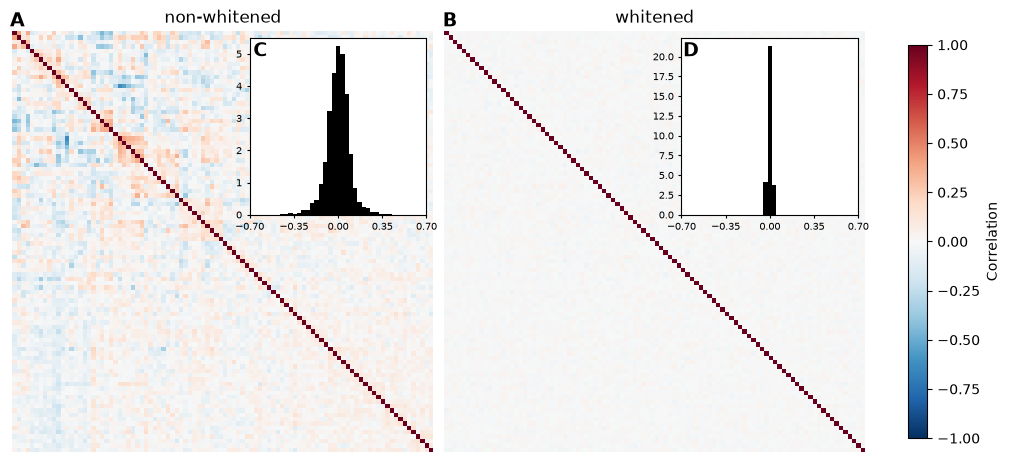

In [39]:
fig, axes = plot_corr_matrices(
    val_cor,
    white_cor,
    labels=None,
    titles=('non-whitened', 'whitened'),
    bins=41,
)
plt.show()

## non-ortho basis example

In [40]:
X = torch.randn(500, 2)
B = torch.tensor(
    [[0, 1], 
     [2, 2]], 
    dtype=torch.float32
)
Q = torch.tensor(
    [[0, -2], 
     [-2, 0]], 
    dtype=torch.float32
)

/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


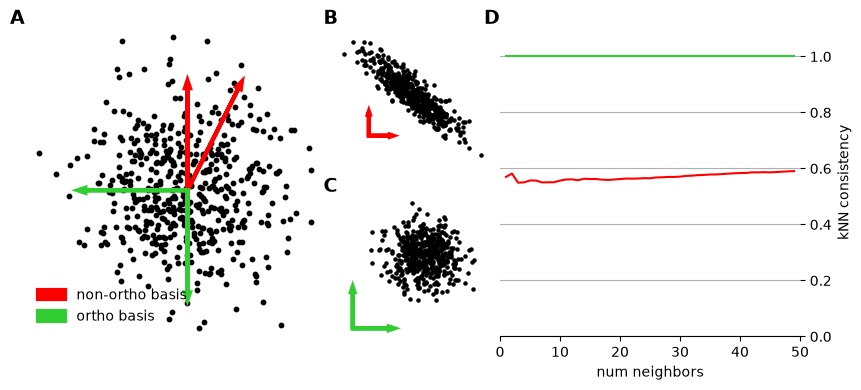

In [43]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

fig = plt.figure(figsize=(10, 4))

# Main layout: left | center | right
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.5, 1], wspace=0.05)

axs_left = fig.add_subplot(gs[0])
axs_right = fig.add_subplot(gs[2])

# Split the middle column vertically
gs_middle = GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs[1],
    wspace=0.0,
)

axs_center_top = fig.add_subplot(gs_middle[0])
axs_center_bottom = fig.add_subplot(gs_middle[1])

colors = {
    'data': 'black',
    'non-ortho': 'r',
    'ortho': 'limegreen',
}

axs_left.scatter(X[:, 0], X[:, 1], color=colors['data'], s=10)
axs_left.arrow(0, 0, B[0, 0], B[1, 0], color=colors['non-ortho'], linewidth=3, head_width=0.1, label='non-ortho basis')
axs_left.arrow(0, 0, B[0, 1], B[1, 1], color=colors['non-ortho'], linewidth=3, head_width=0.1)
axs_left.arrow(0, 0, Q[0, 0], Q[1, 0], color=colors['ortho'], linewidth=3, head_width=0.1, label='ortho basis')
axs_left.arrow(0, 0, Q[0, 1], Q[1, 1], color=colors['ortho'], linewidth=3, head_width=0.1)
axs_left.axis('equal')
axs_left.set_xticks([])
axs_left.set_yticks([])
for spine in axs_left.spines.values():
    spine.set_visible(False)
axs_left.legend(frameon=False, loc='lower left')
axs_left.text(
    0.0, 1.0, 'A',
    transform=axs_left.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

XB = X @ torch.linalg.inv(B).T
axs_center_top.scatter(XB[:, 0], XB[:, 1], color=colors['data'], s=5)
axs_center_top.arrow(-2, -2, 0, 1, color=colors['non-ortho'], linewidth=3, head_width=0.1)
axs_center_top.arrow(-2, -2, 1, 0, color=colors['non-ortho'], linewidth=3, head_width=0.1)
axs_center_top.axis('equal')
axs_center_top.set_xticks([])
axs_center_top.set_yticks([])
for spine in axs_center_top.spines.values():
    spine.set_visible(False)
axs_center_top.text(
    0.0, 1.0, 'B',
    transform=axs_center_top.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

XQ = X @ torch.linalg.inv(Q).T
axs_center_bottom.scatter(XQ[:, 0], XQ[:, 1], color=colors['data'], s=5)
axs_center_bottom.arrow(-2, -2, 0, 1, color=colors['ortho'], linewidth=3, head_width=0.1)
axs_center_bottom.arrow(-2, -2, 1, 0, color=colors['ortho'], linewidth=3, head_width=0.1)
axs_center_bottom.axis('equal')
axs_center_bottom.set_xticks([])
axs_center_bottom.set_yticks([])
for spine in axs_center_bottom.spines.values():
    spine.set_visible(False)
axs_center_bottom.text(
    0.0, 1.0, 'C',
    transform=axs_center_bottom.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

knn_curve, k_range = get_knn_curve([X, XB], k_range=np.unique(np.arange(1, 50)))
axs_right.plot(k_range, knn_curve[0], color=colors['non-ortho'])
knn_curve, k_range = get_knn_curve([X, XQ], k_range=np.unique(np.arange(1, 50)))
axs_right.plot(k_range, knn_curve[0], color=colors['ortho'])
axs_right.set_xlabel('num neighbors')
axs_right.set_ylabel('kNN consistency')
axs_right.yaxis.set_label_position('right')
axs_right.yaxis.tick_right()
axs_right.set_xlim(0, 50)
axs_right.set_ylim(0, 1.1)
axs_right.spines['top'].set_visible(False)
axs_right.spines['left'].set_visible(False)
axs_right.spines['right'].set_visible(False)
# axs_right.spines['bottom'].set_visible(False)
axs_right.grid(axis='y')
axs_right.text(
    0.0, 1.0, 'D',
    transform=axs_right.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

# plt.tight_layout()
plt.show()

# rfs

In [44]:
paths = [
    '../training/runs/sigma4/sigma4_size17_seed0',
    '../training/runs/sigma4/sigma4_size17_seed42',
    '../training/runs/sigma4/sigma4_size17_seed123',
]

new_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device, strict=False)
    new_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [45]:
from sensorium.utility.scores import get_correlations

base_scores = []
for model in models:
    model_scores = get_correlations(model, dataloaders['validation'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    base_scores.append(model_scores)

new_scores = []
for model in new_models:
    model_scores = get_correlations(model, dataloaders['validation'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    new_scores.append(model_scores)

performance = {
    "Gaussian": base_scores,
    "New": new_scores,
}

In [46]:
h, w = 28, 56
gauss_grids = []
for model in models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grids.append(grid)

    gauss_grids.append(grids)

In [47]:
new_grids = []
for model in new_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    new_grids.append(grids)

In [48]:
model_seeds = [9, 87, 333]
model_types = {
    "Gaussian": gauss_grids,
    "New": new_grids,
}

num_mice = 7
num_models = len(model_seeds)

In [49]:
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)
    metric[type_name] = model_avgs

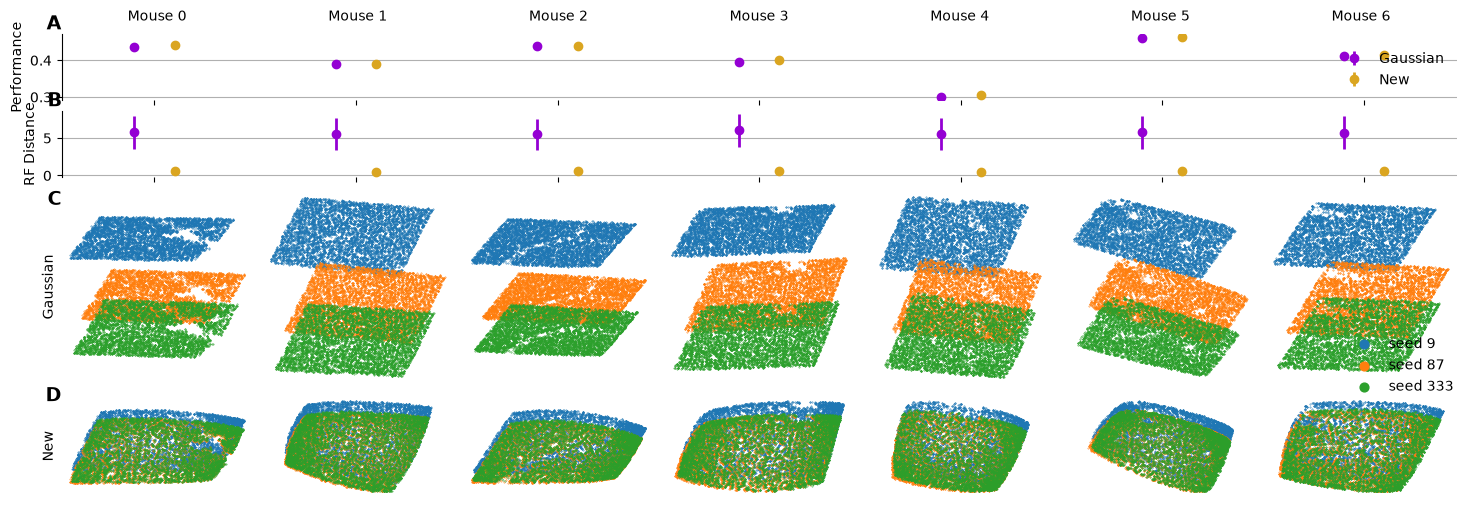

In [54]:
fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(
    4, 7,
    height_ratios=[1, 1, 3, 1.5],
    hspace=0.1,
    wspace=0.05,
)

# Two metric axes, each spanning all 4 columns
ax_performance = fig.add_subplot(gs[0, :])
ax_metric = fig.add_subplot(gs[1, :])

# Bottom: 2 x 4 grid of point plots
axs = np.empty((2, 7), dtype=object)

for row in range(2):
    for col in range(7):
        axs[row, col] = fig.add_subplot(gs[row + 2, col])

model_colors = {
    "Gaussian": "darkviolet",
    "New": "goldenrod",
}

for ax, metric_name, metric_data in [
    (ax_performance, "Performance", performance),
    (ax_metric, "RF Distance", metric),
]:

    offsets = [-0.1, 0.1]
    for model_idx, (type_name, values) in enumerate(metric_data.items()):

        # values: [seed, mouse]
        values = np.asarray(values)

        means = values.mean(axis=0)
        stds = values.std(axis=0)

        x = np.arange(num_mice) + offsets[model_idx]
        
        ax.errorbar(
            x,
            means,
            yerr=stds,
            fmt='o',
            # capsize=4,
            # capthick=2,
            linewidth=2,
            label=type_name,
            color=model_colors[type_name],
        )

    ax.set_xticks(np.arange(num_mice))
    ax.set_xticklabels([f"" for i in range(num_mice)])
    margin = 0.46
    ax.set_xlim(0 - margin, 6 + margin)

    ax.set_ylabel(metric_name)

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y')


for row_idx, (type_name, grids) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):

        ax = axs[row_idx, mouse_idx]

        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]

            ax.scatter(
                grid[:, 0],
                grid[:, 1],
                alpha=1,
                s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )

        ax.set_aspect('equal')

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks([])
        ax.set_yticks([])

        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90)

ax_performance.legend(frameon=False, loc='lower right')

handles, labels = axs[0, 0].get_legend_handles_labels()

axs[0, 6].legend(
    handles,
    labels,
    bbox_to_anchor=(1.05, -0.15),
    loc='lower right',
    markerscale=20,
    frameon=False,
)

for mouse_idx in range(num_mice):
    ax = axs[0, mouse_idx]
    bbox = ax.get_position()

    fig.text(
        bbox.x0 + bbox.width / 2,
        0.92,
        f"Mouse {mouse_idx}",
        ha="center",
        va="top",
    )

ax_performance.text(
    0.0, 1.0, 'A',
    transform=ax_performance.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

ax_metric.text(
    0.0, 1.0, 'B',
    transform=ax_metric.transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

axs[0, 0].text(
    0.0, 1.0, 'C',
    transform=axs[0, 0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

axs[1, 0].text(
    0.0, 1.0, 'D',
    transform=axs[1, 0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.show()

# shifters

In [55]:
base_shifts = []
for model in models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    base_shifts.append(shifts)

In [56]:
new_shifts = []
for model in new_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = -(shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = -(shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    new_shifts.append(shifts)

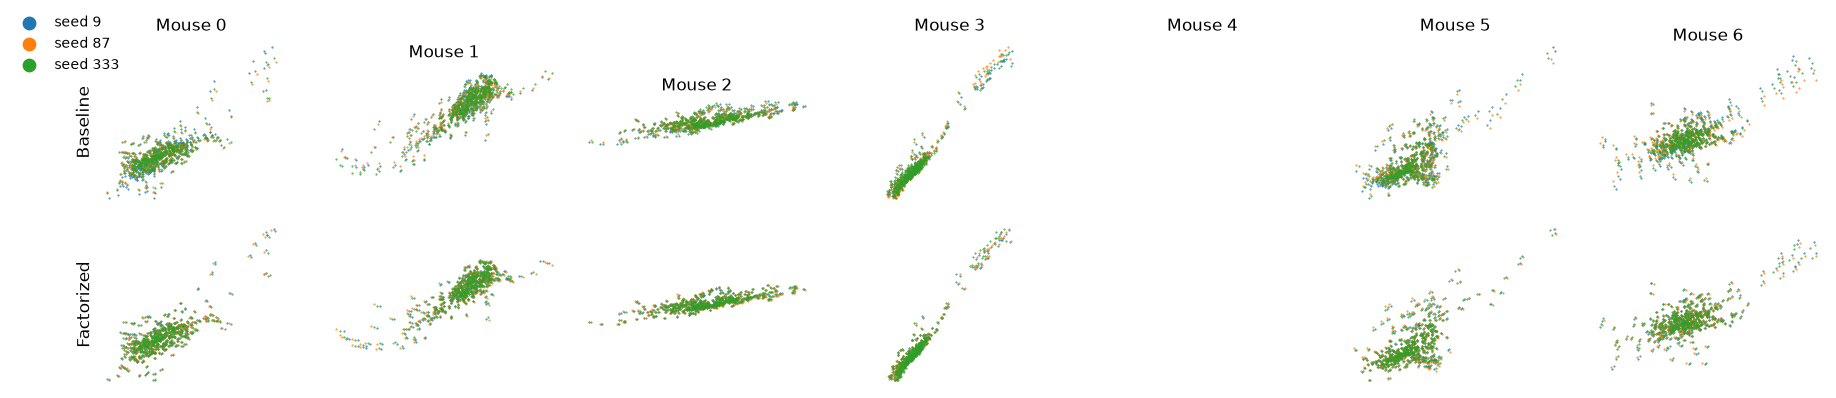

In [57]:
model_seeds = [9, 87, 333]
model_types = {
    "Baseline": base_shifts,
    "Factorized": new_shifts,
}

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, shifts) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            shift = shifts[model_idx][mouse_idx]
            if shift is not None:
                ax.scatter(
                    shift[:, 0], shift[:, 1],
                    alpha=1, s=0.2,
                    label=f"seed {model_seeds[model_idx]}",
                )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=20,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [58]:
means = {}
stds = {}
for type_name, shifts in model_types.items():
    shifts = [torch.cat(g) for g in shifts]
    avgs = []
    print(type_name)
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        d = (shifts[i] - shifts[j]).pow(2).sum(1).sqrt()
        avg = d.mean()
        avgs.append(avg)
        print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
    means[type_name] = torch.tensor(avgs).mean()
    stds[type_name] = torch.tensor(avgs).std()
    print()

Baseline
between seeds: 9, 87: 0.056302208453416824 pixels
between seeds: 9, 333: 0.05052821710705757 pixels
between seeds: 87, 333: 0.04235351085662842 pixels

Factorized
between seeds: 9, 87: 0.02461417205631733 pixels
between seeds: 9, 333: 0.03104083426296711 pixels
between seeds: 87, 333: 0.033367421478033066 pixels



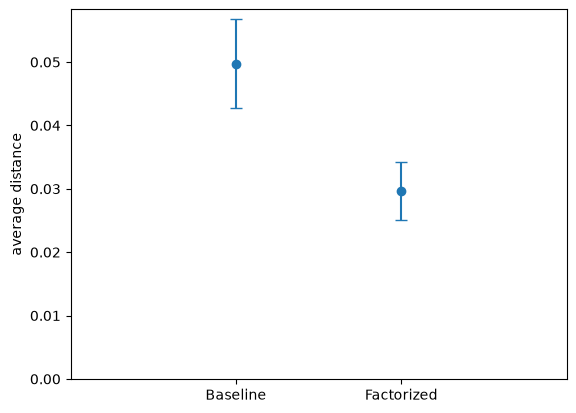

In [59]:
plt.errorbar([0, 1], means.values(), yerr=stds.values(), fmt='o', capsize=4)
plt.xticks([0, 1], means.keys())
plt.xlim(-1, 2)
plt.ylim(0)
plt.ylabel('average distance')
plt.show()

# knn

In [60]:
# load models
paths = [
    '../training/runs/baseline/baseline_white_seed9',
    '../training/runs/baseline/baseline_white_seed87',
    '../training/runs/baseline/baseline_white_seed333',
]

white_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    white_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [61]:
base_readouts = []
for model in models:
    r = torch.cat([model.readout[key].features.detach().squeeze().T for key in data_keys])
    # r = model.whitener.transform_weights(r.T).T.cpu()
    r = r.cpu()
    base_readouts.append(r)

base_knn_curve, k_range = get_knn_curve(base_readouts)
base_ari_curve, n_range = get_ari_curve(base_readouts)

In [62]:
white_readouts = []
for model in white_models:
    r = torch.cat([model.readout[key].features.detach().squeeze().T for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    white_readouts.append(r)

white_knn_curve, k_range = get_knn_curve(white_readouts)
white_ari_curve, n_range = get_ari_curve(white_readouts)

In [63]:
new_non_readouts = []
for model in new_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    # r = model.whitener.transform_weights(r.T).T.cpu()
    r = r.cpu()
    new_non_readouts.append(r)

new_non_knn_curve, k_range = get_knn_curve(new_non_readouts)
new_non_ari_curve, n_range = get_ari_curve(new_non_readouts)

In [64]:
new_readouts = []
for model in new_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    r = r.cpu()
    new_readouts.append(r)

new_knn_curve, k_range = get_knn_curve(new_readouts)
new_ari_curve, n_range = get_ari_curve(new_readouts)

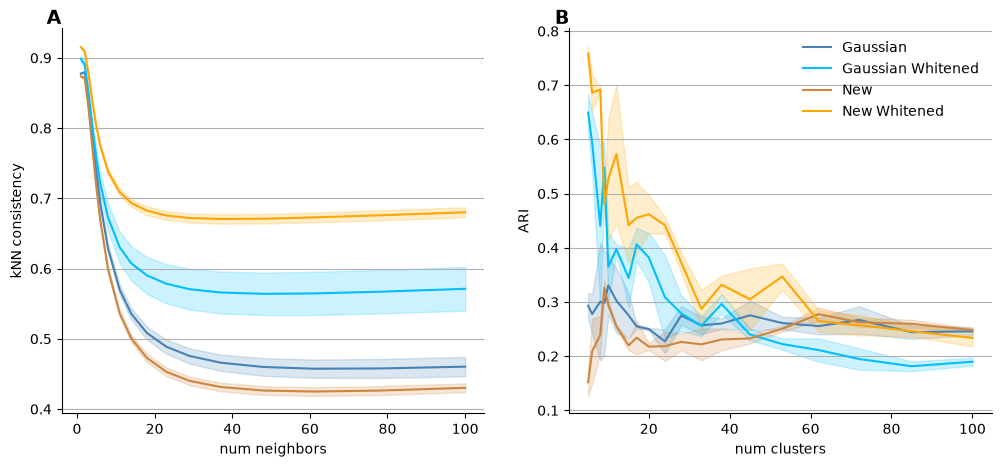

In [65]:
colors = {
    'Gaussian': 'steelblue',
    'Gaussian Whitened': 'deepskyblue',
    'New': 'peru',
    'New Whitened': 'orange',
}
knn_curves = {
    'Gaussian': base_knn_curve,
    'Gaussian Whitened': white_knn_curve,
    'New': new_non_knn_curve,
    'New Whitened': new_knn_curve,
}

ari_curves = {
    'Gaussian': base_ari_curve,
    'Gaussian Whitened': white_ari_curve,
    'New': new_non_ari_curve,
    'New Whitened': new_ari_curve,
}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_curves(ax, x, curves):
    for label, curve in curves.items():
        m, s = np.array(curve[0]), np.array(curve[1])
        ax.plot(x, m, label=label, color=colors[label])
        ax.fill_between(x, m - s, m + s, alpha=0.2, color=colors[label])

plot_curves(axs[0], k_range, knn_curves)
axs[0].set_xlabel('num neighbors')
axs[0].set_ylabel('kNN consistency')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].grid(axis='y')
axs[0].text(
    0.0, 1.0, 'A',
    transform=axs[0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plot_curves(axs[1], n_range, ari_curves)
axs[1].set_xlabel('num clusters')
axs[1].set_ylabel('ARI')
axs[1].legend(frameon=False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].grid(axis='y')
axs[1].text(
    0.0, 1.0, 'B',
    transform=axs[1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.show()